In [2]:
# Bibliotecas e configurações gerais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import xlrd
from datetime import datetime

# Somente para reprodutibilidade
np.random.seed(42)

# Configurações visuais
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (14,5)
plt.rcParams["figure.dpi"] = 100

# Caminhos
RAW     = Path("../data/raw")
PROC    = Path("../data/processed")
PROC.mkdir(parents=True, exist_ok=True)

print("Setup configurado")

Setup configurado


In [3]:
# Célula 2: Leitura dos arquivos
def ler_cepea(caminho):
    # Abre ignorando a corrupção reportada pelo xlrd
    wb = xlrd.open_workbook(
        caminho,
        ignore_workbook_corruption=True
    )
    # Pega a primeira aba
    sheet = wb.sheet_by_index(0)

    # Converte para DataFrame
    dados = []
    for i in range(sheet.nrows):
        dados.append(sheet.row_values(i))

    df = pd.DataFrame(dados)
    # Primeira linha vira cabeçalho
    df.columns = df.iloc[0]
    df = df[1:].reset_index(drop=True)
    return df

# Lendo os três arquivos
df_boi   = ler_cepea(RAW / "cepea-consulta-boigordo-20260418230100.xls")
df_milho = ler_cepea(RAW / "cepea-consulta-milho-20260418225845.xls")
df_soja  = ler_cepea(RAW / "cepea-consulta-soja-20260418230026.xls")

# Diagnóstico rápido
for nome, df in [("Boi Gordo", df_boi), ("Milho", df_milho), ("Soja", df_soja)]:
    print(f"\n{'='*80}")
    print(f"{nome}")
    print(f"Shape: {df.shape}")
    print(f"Colunas: {df.columns.tolist()}")
    print(df.head(3))


Boi Gordo
Shape: (1560, 2)
Colunas: ['Boi | INDICADOR DO BOI GORDO CEPEA/ESALQ', '']
0 Boi | INDICADOR DO BOI GORDO CEPEA/ESALQ  \
0                                     Nota   
1                                    Fonte   
2                                     Data   

0                                                     
0  por arroba, descontado o Prazo de Pagamento pe...  
1                                              Cepea  
2                                              Valor  

Milho
Shape: (1561, 3)
Colunas: ['Milho | INDICADOR DO MILHO ESALQ/BM&FBOVESPA', '', '']
0 Milho | INDICADOR DO MILHO ESALQ/BM&FBOVESPA  \
0                                         Nota   
1                                        Fonte   
2                                         Data   

0                                                                  
0  à vista por saca de 60 kg, descontado o Prazo ...               
1                                              Cepea               
2             

In [4]:
# Célula 3: Limpeza e padronização dos dados CEPEA
def ler_cepea_limpo(caminho, nome_produto):
    wb = xlrd.open_workbook(caminho, ignore_workbook_corruption=True)
    sheet = wb.sheet_by_index(0)

    dados = []
    for i in range(sheet.nrows):
        dados.append(sheet.row_values(i))

    df = pd.DataFrame(dados)

    # Linha 3 = cabeçalho real (Data, Valor...)
    df.columns = df.iloc[3]
    df = df[4:].reset_index(drop=True)

    # Mostra colunas pra debug
    print(f"[{nome_produto}] Colunas: {df.columns.tolist()}")

    # Identifica colunas de preço em R$ e US$
    colunas = df.columns.tolist()
    col_rs  = [c for c in colunas if 'R$' in str(c) or c == 'Valor']
    col_usd = [c for c in colunas if 'US$' in str(c)]
    col_data = [c for c in colunas if c == 'Data'][0]

    # Converte data
    df['data'] = pd.to_datetime(df[col_data], format='%d/%m/%Y', errors='coerce')

    # Converte R$
    df['preco_rs'] = (
        df[col_rs[0]]
        .astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
    )
    df['preco_rs'] = pd.to_numeric(df['preco_rs'], errors='coerce')

    # Converte US$ se existir
    if col_usd:
        df['preco_usd'] = (
            df[col_usd[0]]
            .astype(str)
            .str.replace('.', '', regex=False)
            .str.replace(',', '.', regex=False)
        )
        df['preco_usd'] = pd.to_numeric(df['preco_usd'], errors='coerce')

    # Monta colunas finais
    df['produto'] = nome_produto
    colunas_finais = ['data', 'preco_rs']
    if col_usd:
        colunas_finais.append('preco_usd')
    colunas_finais.append('produto')

    df = df[colunas_finais].dropna(subset=['data', 'preco_rs']).reset_index(drop=True)
    return df

# Lendo arquivos formatados
df_boi   = ler_cepea_limpo(RAW / "cepea-consulta-boigordo-20260418230100.xls", "boi_gordo")
df_milho = ler_cepea_limpo(RAW / "cepea-consulta-milho-20260418225845.xls",    "milho")
df_soja  = ler_cepea_limpo(RAW / "cepea-consulta-soja-20260418230026.xls",     "soja")

for nome, df in [("Boi Gordo", df_boi), ("Milho", df_milho), ("Soja", df_soja)]:
    print(f"\n{'='*80}")
    print(f"{nome}")
    print(f"Shape: {df.shape}")
    print(f"Colunas: {df.columns.tolist()}")
    print(f"Período: {df['data'].min()} → {df['data'].max()}")
    print(f"Preço R$ — mín: {df['preco_rs'].min():.2f} | máx: {df['preco_rs'].max():.2f}")
    print(df.head(3))

[boi_gordo] Colunas: ['Data', 'Valor']
[milho] Colunas: ['Data', 'À vista R$', 'À vista US$']
[soja] Colunas: ['Data', 'À vista R$', 'À vista US$']

Boi Gordo
Shape: (1557, 3)
Colunas: ['data', 'preco_rs', 'produto']
Período: 2020-01-02 00:00:00 → 2026-03-31 00:00:00
Preço R$ — mín: 186.10 | máx: 356.00
3       data  preco_rs    produto
0 2020-01-02    192.95  boi_gordo
1 2020-01-03    196.70  boi_gordo
2 2020-01-06    196.40  boi_gordo

Milho
Shape: (1558, 4)
Colunas: ['data', 'preco_rs', 'preco_usd', 'produto']
Período: 2020-01-02 00:00:00 → 2026-03-31 00:00:00
Preço R$ — mín: 46.81 | máx: 103.90
3       data  preco_rs  preco_usd produto
0 2020-01-02     48.43      12.04   milho
1 2020-01-03     48.91      12.07   milho
2 2020-01-06     48.99      12.03   milho

Soja
Shape: (1558, 4)
Colunas: ['data', 'preco_rs', 'preco_usd', 'produto']
Período: 2020-01-02 00:00:00 → 2026-03-31 00:00:00
Preço R$ — mín: 84.73 | máx: 207.14
3       data  preco_rs  preco_usd produto
0 2020-01-02     88.

In [5]:
# Célula 4: Salvando os dados processados
df_boi.to_csv(PROC / "cepea_boigordo.csv", index=False)
df_milho.to_csv(PROC / "cepea_milho.csv", index=False)
df_soja.to_csv(PROC / "cepea_soja.csv", index=False)

print("Arquivos salvos em data/processed/")
print(f"   cepea_boigordo.csv — {len(df_boi)} registros")
print(f"   cepea_milho.csv    — {len(df_milho)} registros")
print(f"   cepea_soja.csv     — {len(df_soja)} registros")

Arquivos salvos em data/processed/
   cepea_boigordo.csv — 1557 registros
   cepea_milho.csv    — 1558 registros
   cepea_soja.csv     — 1558 registros


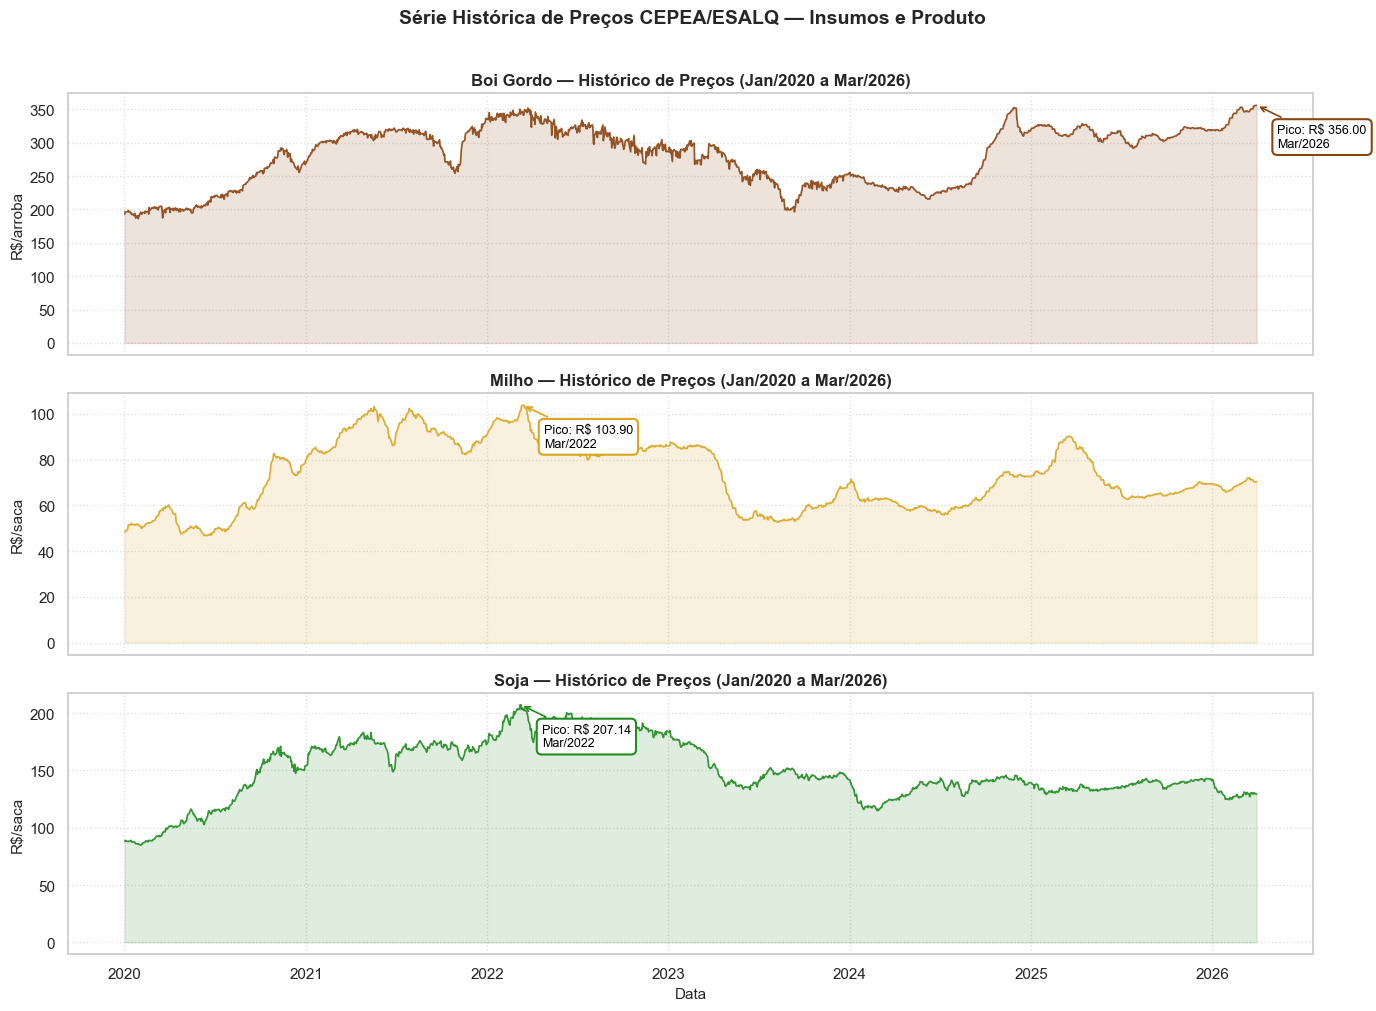

Gráfico salvo


In [6]:
# Célula 5: Primeiro gráfico: Evolução histórica dos preços
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

datasets = [
    (df_boi,   "Boi Gordo",  "R$/arroba", "#8B4513"),
    (df_milho, "Milho",      "R$/saca",   "#DAA520"),
    (df_soja,  "Soja",       "R$/saca",   "#228B22"),
]

for ax, (df, nome, unidade, cor) in zip(axes, datasets):
    ax.plot(df['data'], df['preco_rs'], color=cor, linewidth=1.2, alpha=0.9)
    ax.fill_between(df['data'], df['preco_rs'], alpha=0.15, color=cor)
    ax.set_ylabel(f"{unidade}", fontsize=11)
    ax.set_title(f"{nome} — Histórico de Preços (Jan/2020 a Mar/2026)",
                 fontsize=12, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)

    # Destaca pico
    idx_max = df['preco_rs'].idxmax()
    ax.annotate(
        f"Pico: R$ {df['preco_rs'].max():.2f}\n{df.loc[idx_max,'data'].strftime('%b/%Y')}",
        xy=(df.loc[idx_max,'data'], df['preco_rs'].max()),
        xytext=(15, -30), textcoords='offset points',
        fontsize=9, color='black',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=cor, linewidth=1.5),
        arrowprops=dict(arrowstyle='->', color=cor, lw=1.2)
    )

plt.xlabel("Data", fontsize=11)
plt.suptitle("Série Histórica de Preços CEPEA/ESALQ — Insumos e Produto",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PROC / "grafico_serie_historica_cepea.png", dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico salvo")

In [7]:
# Célula 6: Simulação de rebanho
print("--- SIMULANDO REBANHO DE 500 ANIMAIS ---")

# ── Parâmetros da fazenda ─────────────────────────────────────────────────
N_ANIMAIS      = 500
DATA_INICIO    = pd.Timestamp("2024-07-01")  # entrada no confinamento
INTERVALO_DIAS = 28                           # pesagem a cada 28 dias
N_PESAGENS     = 18                           # 18 meses de monitoramento
PESO_META      = 520                          # kg para abate

# ── Raças disponíveis ─────────────────────────────────────────────────────
racas = {
    "Nelore":         {"peso_medio": 280, "gmd_medio": 1.05, "gmd_std": 0.20},
    "Angus":          {"peso_medio": 310, "gmd_medio": 1.25, "gmd_std": 0.18},
    "Brahman":        {"peso_medio": 270, "gmd_medio": 0.95, "gmd_std": 0.22},
    "Cruzado Nelore": {"peso_medio": 295, "gmd_medio": 1.15, "gmd_std": 0.19},
    "Simental":       {"peso_medio": 320, "gmd_medio": 1.30, "gmd_std": 0.17},
}

# Distribuição realista de raças numa fazenda do Centro-Oeste
pesos_racas = [0.40, 0.15, 0.15, 0.20, 0.10]  # Nelore dominante

# ── Gerando animais ───────────────────────────────────────────────────────
animais = []
for i in range(1, N_ANIMAIS + 1):
    raca = np.random.choice(list(racas.keys()), p=pesos_racas)
    params = racas[raca]

    # Peso de entrada com variação individual
    peso_entrada = np.random.normal(params["peso_medio"], 20)
    peso_entrada = max(220, min(380, peso_entrada))  # limita entre 220-380kg

    # GMD individual — cada animal tem sua própria taxa de ganho
    gmd_individual = np.random.normal(params["gmd_medio"], params["gmd_std"])
    gmd_individual = max(0.4, min(1.8, gmd_individual))  # limita extremos

    # Lote (1 a 10)
    lote = np.random.randint(1, 11)

    animais.append({
        "id_animal":    i,
        "brinco":       f"BR{i:04d}",
        "raca":         raca,
        "lote":         lote,
        "peso_entrada": round(peso_entrada, 1),
        "gmd_base":     round(gmd_individual, 3),
        "data_entrada": DATA_INICIO,
        "status":       "ativo"
    })

df_animais = pd.DataFrame(animais)

print(f"{len(df_animais)} animais gerados")
print(f"\nDistribuição por raça:")
print(df_animais['raca'].value_counts())
print(f"\nPeso médio de entrada: {df_animais['peso_entrada'].mean():.1f} kg")
print(f"GMD médio: {df_animais['gmd_base'].mean():.3f} kg/dia")
print(df_animais.head(5))

--- SIMULANDO REBANHO DE 500 ANIMAIS ---
500 animais gerados

Distribuição por raça:
raca
Nelore            199
Cruzado Nelore    100
Brahman            82
Angus              62
Simental           57
Name: count, dtype: int64

Peso médio de entrada: 290.1 kg
GMD médio: 1.112 kg/dia
   id_animal  brinco            raca  lote  peso_entrada  gmd_base  \
0          1  BR0001          Nelore     3         257.8     1.114   
1          2  BR0002          Nelore     8         239.8     0.951   
2          3  BR0003  Cruzado Nelore     5         285.6     1.253   
3          4  BR0004         Brahman    10         270.4     0.856   
4          5  BR0005          Nelore     7         284.4     0.896   

  data_entrada status  
0   2024-07-01  ativo  
1   2024-07-01  ativo  
2   2024-07-01  ativo  
3   2024-07-01  ativo  
4   2024-07-01  ativo  


In [8]:
# Célula 7: Histórico de Pesagens
print("--- GERANDO HISTÓRICO DE PESAGENS ---")

pesagens = []

for _, animal in df_animais.iterrows():
    peso_atual = animal['peso_entrada']

    for n in range(N_PESAGENS):
        data_pesagem = DATA_INICIO + pd.Timedelta(days=n * INTERVALO_DIAS)

        # GMD com variação diária realista — clima, saúde, estresse
        variacao = np.random.normal(0, 0.08)
        gmd_dia   = max(0.3, animal['gmd_base'] + variacao)

        # Ganho no período de 28 dias
        ganho_periodo = gmd_dia * INTERVALO_DIAS
        peso_atual    = round(peso_atual + ganho_periodo, 1)

        # Arroba atual (1 @ = 15kg, rendimento 50% do peso vivo)
        arroba_atual = round((peso_atual * 0.50) / 15, 2)

        pesagens.append({
            "id_pesagem":   len(pesagens) + 1,
            "id_animal":    animal['id_animal'],
            "brinco":       animal['brinco'],
            "raca":         animal['raca'],
            "lote":         animal['lote'],
            "data_pesagem": data_pesagem,
            "dias_conf":    n * INTERVALO_DIAS,
            "peso_kg":      peso_atual,
            "gmd_periodo":  round(gmd_dia, 3),
            "arroba_atual": arroba_atual,
        })

        # Para se atingiu o peso de abate
        if peso_atual >= PESO_META:
            break

df_pesagens = pd.DataFrame(pesagens)

print(f"{len(df_pesagens)} registros de pesagem gerados")
print(f"   Animais: {df_pesagens['id_animal'].nunique()}")
print(f"   Período: {df_pesagens['data_pesagem'].min().date()} → {df_pesagens['data_pesagem'].max().date()}")
print(f"\nEstatísticas de peso:")
print(f"   Peso médio final: {df_pesagens.groupby('id_animal')['peso_kg'].last().mean():.1f} kg")
print(f"   GMD médio geral:  {df_pesagens['gmd_periodo'].mean():.3f} kg/dia")
print(f"\nAmostra:")
print(df_pesagens.head(8))

--- GERANDO HISTÓRICO DE PESAGENS ---
4148 registros de pesagem gerados
   Animais: 500
   Período: 2024-07-01 → 2025-10-20

Estatísticas de peso:
   Peso médio final: 535.2 kg
   GMD médio geral:  1.055 kg/dia

Amostra:
   id_pesagem  id_animal  brinco    raca  lote data_pesagem  dias_conf  \
0           1          1  BR0001  Nelore     3   2024-07-01          0   
1           2          1  BR0001  Nelore     3   2024-07-29         28   
2           3          1  BR0001  Nelore     3   2024-08-26         56   
3           4          1  BR0001  Nelore     3   2024-09-23         84   
4           5          1  BR0001  Nelore     3   2024-10-21        112   
5           6          1  BR0001  Nelore     3   2024-11-18        140   
6           7          1  BR0001  Nelore     3   2024-12-16        168   
7           8          1  BR0001  Nelore     3   2025-01-13        196   

   peso_kg  gmd_periodo  arroba_atual  
0    293.0        1.259          9.77  
1    325.0        1.142         

In [9]:
# Célula 8: Cruzando pesagens com preço do boi gordo (valor de mercado)
print("--- CALCULANDO VALOR DE MERCADO POR PESAGEM ---")

# Prepara série de preços do boi
df_preco_boi = df_boi[['data', 'preco_rs']].copy()
df_preco_boi = df_preco_boi.sort_values('data').reset_index(drop=True)

# Merge por data mais próxima
df_pesagens_sorted = df_pesagens.sort_values('data_pesagem').reset_index(drop=True)

df_pesagens_valor = pd.merge_asof(
    df_pesagens_sorted,
    df_preco_boi,
    left_on='data_pesagem',
    right_on='data',
    direction='nearest'
)

# Renomeia após o merge
df_pesagens_valor = df_pesagens_valor.rename(columns={'preco_rs': 'preco_arroba_rs'})

# Valor mercado individual
df_pesagens_valor['valor_mercado_rs'] = round(
    df_pesagens_valor['arroba_atual'] * df_pesagens_valor['preco_arroba_rs'], 2
)

# Remove coluna data duplicada
df_pesagens_valor = df_pesagens_valor.drop(columns='data')

print(f"Valor de mercado calculado para {len(df_pesagens_valor)} pesagens")
print(f"\nEstatísticas de valor:")
print(f"   Valor médio por animal (última pesagem): R$ {df_pesagens_valor.groupby('id_animal')['valor_mercado_rs'].last().mean():,.2f}")
print(f"   Valor total do rebanho (última pesagem): R$ {df_pesagens_valor.groupby('id_animal')['valor_mercado_rs'].last().sum():,.2f}")
print(f"   Preço arroba usado (mais recente): R$ {df_pesagens_valor['preco_arroba_rs'].iloc[-1]:.2f}")
print(f"\nAmostra:")
print(df_pesagens_valor[['brinco','raca','data_pesagem','peso_kg',
                          'arroba_atual','preco_arroba_rs','valor_mercado_rs']].head(5))

--- CALCULANDO VALOR DE MERCADO POR PESAGEM ---
Valor de mercado calculado para 4148 pesagens

Estatísticas de valor:
   Valor médio por animal (última pesagem): R$ 5,725.46
   Valor total do rebanho (última pesagem): R$ 2,862,730.23
   Preço arroba usado (mais recente): R$ 310.20

Amostra:
   brinco            raca data_pesagem  peso_kg  arroba_atual  \
0  BR0001          Nelore   2024-07-01    293.0          9.77   
1  BR0144         Brahman   2024-07-01    302.1         10.07   
2  BR0303  Cruzado Nelore   2024-07-01    317.7         10.59   
3  BR0188           Angus   2024-07-01    351.3         11.71   
4  BR0302          Nelore   2024-07-01    318.0         10.60   

   preco_arroba_rs  valor_mercado_rs  
0           225.65           2204.60  
1           225.65           2272.30  
2           225.65           2389.63  
3           225.65           2642.36  
4           225.65           2391.89  


In [10]:
# Célula 9: Simulação do Histórico Sanitário
print("--- GERANDO HISTÓRICO SANITÁRIO ---")

# ── Eventos sanitários possíveis ─────────────────────────────────────────
eventos_sanitarios = {
    # Vacinações obrigatórias — todos os animais
    "Febre Aftosa":        {"tipo": "vacina",        "custo": 4.50,  "freq": "obrigatoria"},
    "Brucelose":           {"tipo": "vacina",        "custo": 6.20,  "freq": "obrigatoria"},
    "Raiva":               {"tipo": "vacina",        "custo": 3.80,  "freq": "obrigatoria"},
    # Vermifugações — todos os animais
    "Ivermectina":         {"tipo": "vermifugacao",  "custo": 8.90,  "freq": "periodica"},
    "Doramectina":         {"tipo": "vermifugacao",  "custo": 11.20, "freq": "periodica"},
    # Tratamentos — apenas animais com ocorrência
    "Antibiótico":         {"tipo": "tratamento",    "custo": 45.00, "freq": "eventual"},
    "Anti-inflamatório":   {"tipo": "tratamento",    "custo": 28.50, "freq": "eventual"},
    "Suplemento Mineral":  {"tipo": "suplemento",    "custo": 15.30, "freq": "eventual"},
}

sanitario = []

for _, animal in df_animais.iterrows():
    data_entrada = animal['data_entrada']

    # ── Vacinações obrigatórias (todos os animais, datas fixas) ──────────
    for vacina, params in [(k,v) for k,v in eventos_sanitarios.items()
                           if v['freq'] == 'obrigatoria']:
        # Aplicada no 1º mês e reforço no 6º mês
        for meses_offset in [1, 6]:
            data_evento = data_entrada + pd.DateOffset(months=meses_offset)
            sanitario.append({
                "id_animal":   animal['id_animal'],
                "brinco":      animal['brinco'],
                "data_evento": data_evento,
                "tipo":        params['tipo'],
                "produto":     vacina,
                "dose_ml":     round(np.random.uniform(2.0, 5.0), 1),
                "custo_unit":  params['custo'],
            })

    # ── Vermifugações periódicas (todos, a cada 90 dias) ─────────────────
    for n in range(6):  # 6 vermifugações em 18 meses
        data_evento = data_entrada + pd.Timedelta(days=n * 90)
        produto = np.random.choice(["Ivermectina", "Doramectina"])
        sanitario.append({
            "id_animal":   animal['id_animal'],
            "brinco":      animal['brinco'],
            "data_evento": data_evento,
            "tipo":        "vermifugacao",
            "produto":     produto,
            "dose_ml":     round(np.random.uniform(5.0, 10.0), 1),
            "custo_unit":  eventos_sanitarios[produto]['custo'],
        })

    # ── Tratamentos eventuais (20% dos animais têm alguma ocorrência) ────
    if np.random.random() < 0.20:
        n_ocorrencias = np.random.randint(1, 4)
        for _ in range(n_ocorrencias):
            dias_offset = np.random.randint(15, 480)
            data_evento = data_entrada + pd.Timedelta(days=dias_offset)
            produto = np.random.choice(["Antibiótico", "Anti-inflamatório",
                                        "Suplemento Mineral"])
            sanitario.append({
                "id_animal":   animal['id_animal'],
                "brinco":      animal['brinco'],
                "data_evento": data_evento,
                "tipo":        eventos_sanitarios[produto]['tipo'],
                "produto":     produto,
                "dose_ml":     round(np.random.uniform(3.0, 15.0), 1),
                "custo_unit":  eventos_sanitarios[produto]['custo'],
            })

df_sanitario = pd.DataFrame(sanitario)

# Adiciona id sequencial
df_sanitario.insert(0, 'id_evento', range(1, len(df_sanitario) + 1))

# Custo total por evento
df_sanitario['custo_total'] = round(
    df_sanitario['custo_unit'] * df_sanitario['dose_ml'], 2
)

print(f"{len(df_sanitario)} eventos sanitários gerados")
print(f"\nDistribuição por tipo:")
print(df_sanitario['tipo'].value_counts())
print(f"\nCusto sanitário total: R$ {df_sanitario['custo_total'].sum():,.2f}")
print(f"Custo médio por animal: R$ {df_sanitario.groupby('id_animal')['custo_total'].sum().mean():,.2f}")
print(f"\nAmostra:")
print(df_sanitario.head(8))

--- GERANDO HISTÓRICO SANITÁRIO ---
6181 eventos sanitários gerados

Distribuição por tipo:
tipo
vacina          3000
vermifugacao    3000
tratamento       122
suplemento        59
Name: count, dtype: int64

Custo sanitário total: R$ 323,893.05
Custo médio por animal: R$ 647.79

Amostra:
   id_evento  id_animal  brinco data_evento          tipo       produto  \
0          1          1  BR0001  2024-08-01        vacina  Febre Aftosa   
1          2          1  BR0001  2025-01-01        vacina  Febre Aftosa   
2          3          1  BR0001  2024-08-01        vacina     Brucelose   
3          4          1  BR0001  2025-01-01        vacina     Brucelose   
4          5          1  BR0001  2024-08-01        vacina         Raiva   
5          6          1  BR0001  2025-01-01        vacina         Raiva   
6          7          1  BR0001  2024-07-01  vermifugacao   Ivermectina   
7          8          1  BR0001  2024-09-29  vermifugacao   Ivermectina   

   dose_ml  custo_unit  custo_total

In [16]:
# Célula 10: Simulação de Estoque de Insumos
print("--- GERANDO CONSUMO DE INSUMOS ---")

# ── Parâmetros de consumo ─────────────────────────────────────────────────
# Consumo médio de animal por dia
CONSUMO_MILHO_KG    = 4.5
CONSUMO_SOJA_KG     = 1.2
CONSUMO_MINERAL_KG = 0.08

# Preço do sal mineral (Não tem no CEPEA, fixo com variação)
PRECO_MINERAL_RS   = 3.20

estoque = []

# Gerar consumo mensal por lote
for lote in range(1, 11):
    animais_lote = df_animais[df_animais['lote'] == lote]
    n_animais_lote = len(animais_lote)

    for mes in range(18):
        data_ref = DATA_INICIO + pd.DateOffset(months=mes)
        dias_mes = 30

        # Consumo total do lote no mês
        consumo_milho   = round(n_animais_lote * CONSUMO_MILHO_KG   * dias_mes, 1)
        consumo_soja    = round(n_animais_lote * CONSUMO_SOJA_KG    * dias_mes, 1)
        consumo_mineral = round(n_animais_lote * CONSUMO_MINERAL_KG * dias_mes, 1)

        # Busca preço do milho e soja no mês correspondente
        preco_milho_saca = df_milho[
            df_milho['data'] <= data_ref
        ]['preco_rs'].iloc[-1]

        preco_soja_saca = df_soja[
            df_soja['data'] <= data_ref
        ]['preco_rs'].iloc[-1]

        # Converte saca (60kg) pra R$/kg
        preco_milho_kg = round(preco_milho_saca / 60, 4)
        preco_soja_kg  = round(preco_soja_saca  / 60, 4)

        # Custo total por insumo
        custo_milho   = round(consumo_milho   * preco_milho_kg,  2)
        custo_soja    = round(consumo_soja    * preco_soja_kg,   2)
        custo_mineral = round(consumo_mineral * PRECO_MINERAL_RS, 2)

        # Variação realista de estoque — compra antecipada ou atraso
        variacao = np.random.uniform(0.90, 1.10)

        estoque.append({
            "lote":             lote,
            "n_animais":        n_animais_lote,
            "data_ref":         data_ref,
            "insumo":           "milho",
            "consumo_kg":       consumo_milho,
            "preco_rs_kg":      preco_milho_kg,
            "custo_total_rs":   custo_milho,
            "estoque_kg":       round(consumo_milho * variacao, 1),
        })
        estoque.append({
            "lote":             lote,
            "n_animais":        n_animais_lote,
            "data_ref":         data_ref,
            "insumo":           "farelo_soja",
            "consumo_kg":       consumo_soja,
            "preco_rs_kg":      preco_soja_kg,
            "custo_total_rs":   custo_soja,
            "estoque_kg":       round(consumo_soja * variacao, 1),
        })
        estoque.append({
            "lote":             lote,
            "n_animais":        n_animais_lote,
            "data_ref":         data_ref,
            "insumo":           "sal_mineral",
            "consumo_kg":       consumo_mineral,
            "preco_rs_kg":      PRECO_MINERAL_RS,
            "custo_total_rs":   custo_mineral,
            "estoque_kg":       round(consumo_mineral * variacao, 1),
        })

df_estoque = pd.DataFrame(estoque)
df_estoque.insert(0, 'id_estoque', range(1, len(df_estoque) + 1))

print(f"{len(df_estoque)} registros de estoque gerados")
print(f"   Lotes: {df_estoque['lote'].nunique()}")
print(f"   Período: {df_estoque['data_ref'].min().date()} → {df_estoque['data_ref'].max().date()}")
print(f"\nCusto total por insumo (18 meses):")
print(df_estoque.groupby('insumo')['custo_total_rs'].sum().apply(lambda x: f"R$ {x:,.2f}"))
print(f"\nCusto total de insumos: R$ {df_estoque['custo_total_rs'].sum():,.2f}")
print(f"\nAmostra:")
print(df_estoque.head(6))

--- GERANDO CONSUMO DE INSUMOS ---
540 registros de estoque gerados
   Lotes: 10
   Período: 2024-07-01 → 2025-12-01

Custo total por insumo (18 meses):
insumo
farelo_soja      R$ 743,410.80
milho          R$ 1,408,913.97
sal_mineral       R$ 69,120.00
Name: custo_total_rs, dtype: str

Custo total de insumos: R$ 2,221,444.77

Amostra:
   id_estoque  lote  n_animais   data_ref       insumo  consumo_kg  \
0           1     1         46 2024-07-01        milho      6210.0   
1           2     1         46 2024-07-01  farelo_soja      1656.0   
2           3     1         46 2024-07-01  sal_mineral       110.4   
3           4     1         46 2024-08-01        milho      6210.0   
4           5     1         46 2024-08-01  farelo_soja      1656.0   
5           6     1         46 2024-08-01  sal_mineral       110.4   

   preco_rs_kg  custo_total_rs  estoque_kg  
0       0.9553         5932.41      6163.5  
1       2.3372         3870.40      1643.6  
2       3.2000          353.28       